In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Master's Thesis v0.4/TM Project/"

/content/drive/MyDrive/Master's Thesis v0.4/TM Project


In [492]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [782]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.io import loadmat

In [783]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TE'

In [784]:
beta = 0.90

# device 1

In [721]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = 0.0952 * k_0
dy = 0.05 * k_0

# simulation lengths

core_length_x = 2 * k_0 # W
core_length_y = 1.1 * k_0 # H

substrate_length_x = 3.0 * k_0 # Xs
substrate_length_y = 5.025 * k_0 # Ys

rib_length = 0.2 * k_0 # D

cladding_length_y = 0.525 * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.34
n_cladding = 1

In [722]:
weights = [1, 1, 1, 1, 1, 1]
m = 2

In [723]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [724]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-725-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-725-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


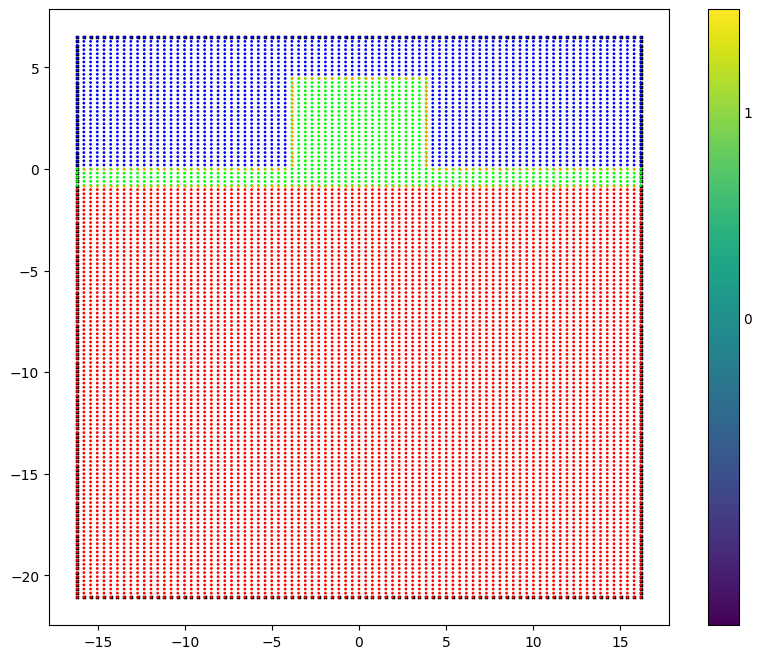

In [725]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [726]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [727]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [728]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [729]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

2.632291398185771e-05


In [730]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

num samples 11645


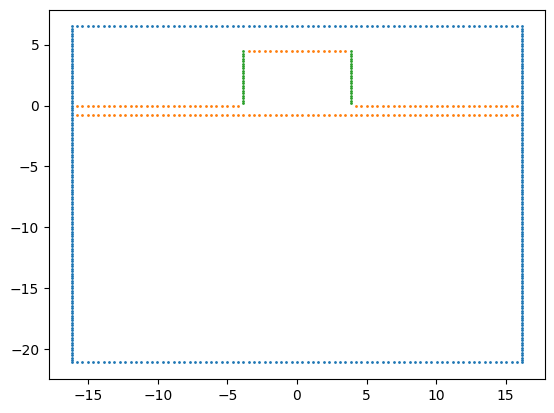

iteration 1 loss1 is 1.07294, loss2 is 1.34923, loss3 is 2.97122, loss4 is 0.0, loss5 is 0.08721, loss6 is 3.43601, total loss 4.596153616905212
3.3409828786539726 11.162166595458984
1.419935442034566 2.0162166595458983


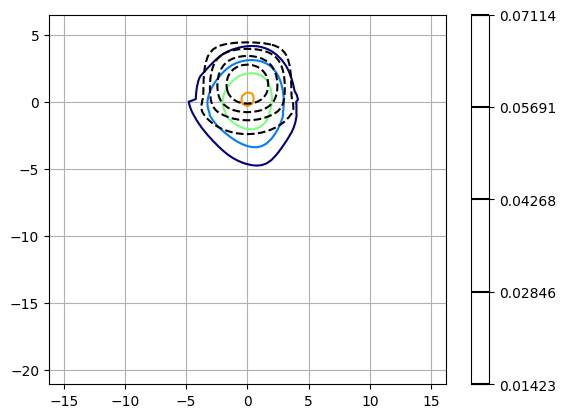

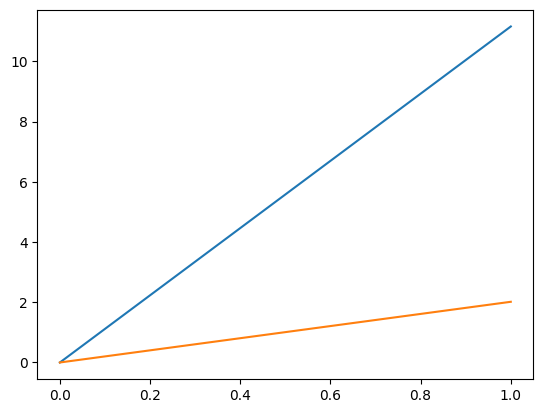

approaching the eigenvalue at 3.3827898055586174 in iteration 443
current learning rate 0.01
learning rate reduced to 0.001
upper and lower bounds: 3.44 3.34
tightened to: 3.3942380909359255 3.376606296645592
eigen value fixed at 3.3826994417727647 in iteration 879
iteration 1001 loss1 is 0.04832, loss2 is 0.00728, loss3 is 2.10751, loss4 is 0.0, loss5 is 0.00102, loss6 is 0.09235, total loss 0.14169356599450111
3.3827088937024556 11.442719459533691
3.3827004750062972 11.442662503607828


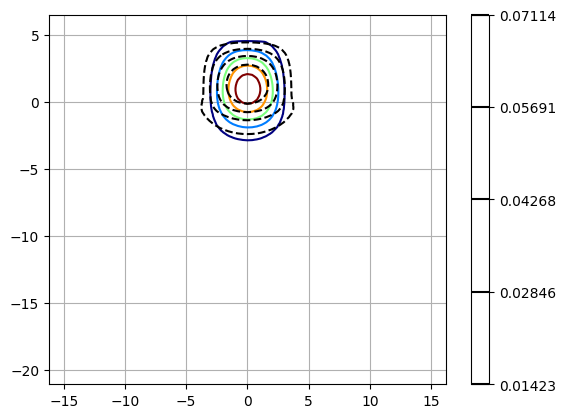

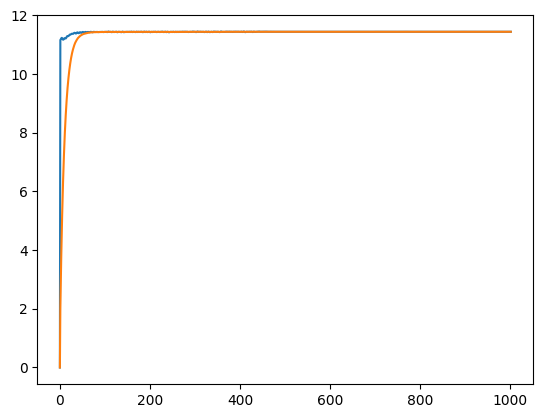

iteration 2001 loss1 is 0.04548, loss2 is 0.00538, loss3 is 2.10591, loss4 is 0.0, loss5 is 0.0008, loss6 is 0.09161, total loss 0.13788539916276932
3.382817292595479 11.443452835083008
3.3827994064617037 11.443331824357657


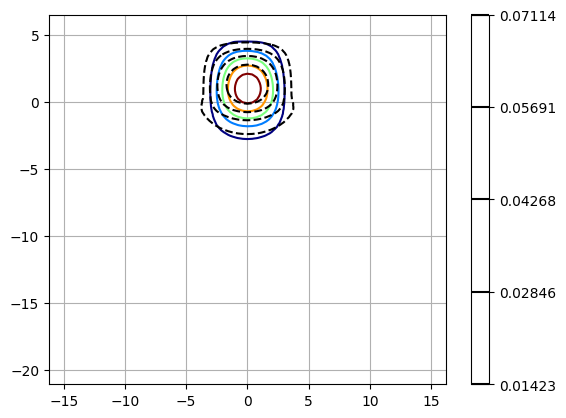

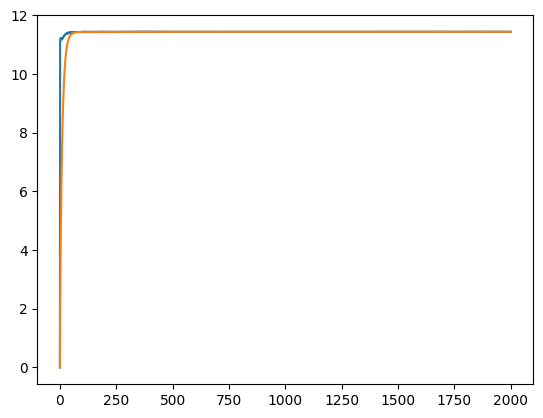

iteration 3001 loss1 is 0.04485, loss2 is 0.00502, loss3 is 2.10544, loss4 is 0.0, loss5 is 0.00047, loss6 is 0.04067, total loss 0.08599625527858734
3.3828491490869816 11.443668365478516
3.382840704946964 11.443611235046074


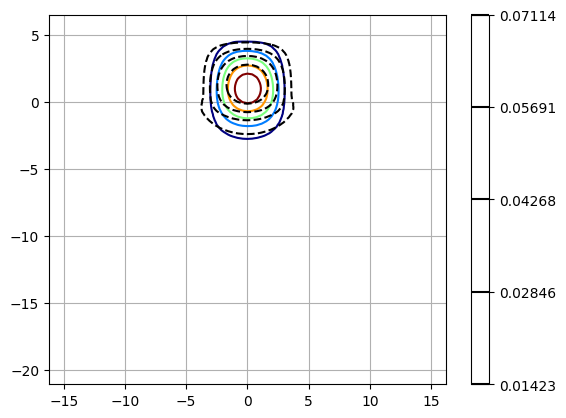

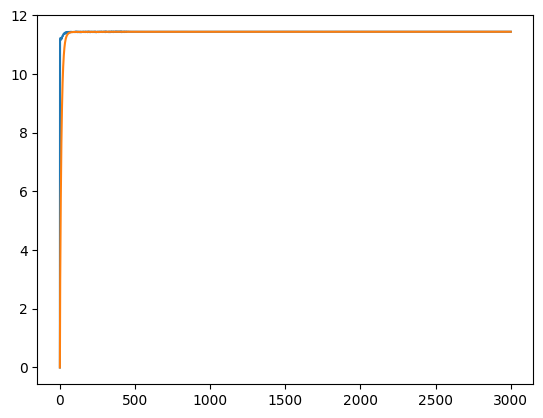

iteration 4001 loss1 is 0.04455, loss2 is 0.00477, loss3 is 2.1057, loss4 is 0.0, loss5 is 0.00045, loss6 is 0.03768, total loss 0.08267737179994583
3.382831811299166 11.443551063537598
3.382843664159753 11.443631256145782


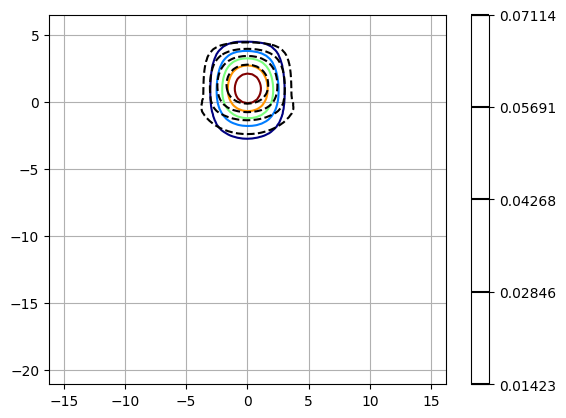

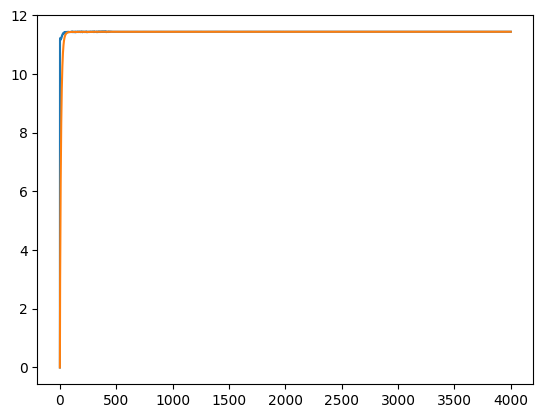

iteration 5001 loss1 is 0.04432, loss2 is 0.00453, loss3 is 2.10575, loss4 is 0.0, loss5 is 0.00045, loss6 is 0.04337, total loss 0.08814016357064247
3.382827864473263 11.443524360656738
3.3828299393502994 11.44353839856475


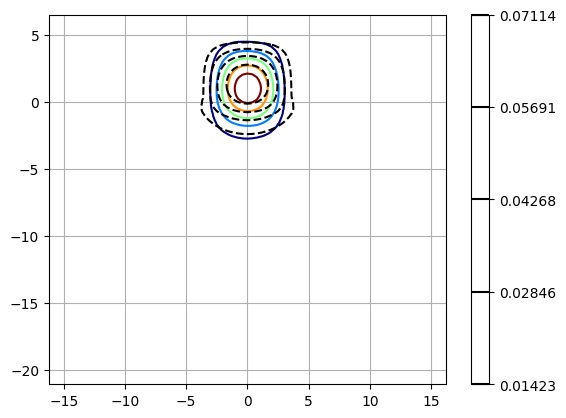

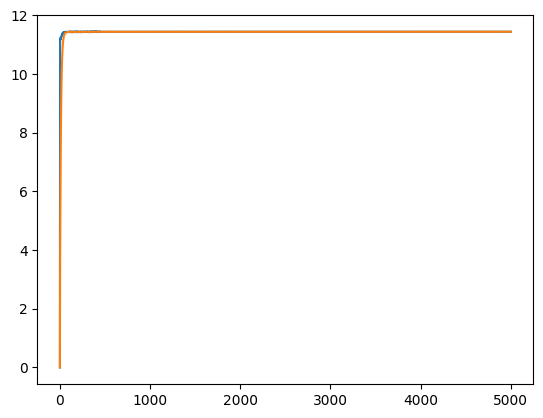

In [731]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(5001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [732]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): DRBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [733]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

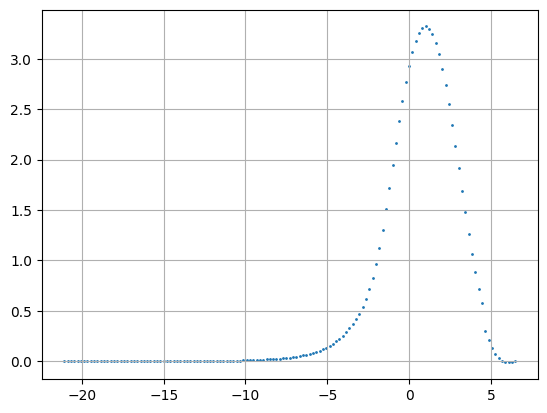

In [734]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [739]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 2*dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

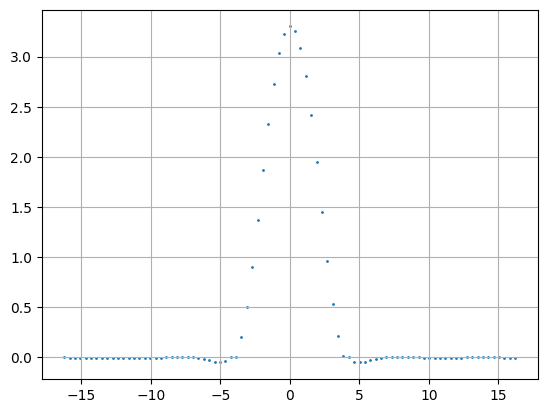

In [740]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [753]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy, num_modes=1)

In [754]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.39083654]


In [755]:
u = u/torch.linalg.norm(u, dim=0, keepdims=True)/np.max(u_fd)
u_fd = u_fd/np.max(u_fd)

/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1089: RuntimeWarning: invalid value encountered in cast
  return self.numpy().astype(dtype, copy=False)
/usr/local/lib/python3.10/dist-packages/matplotlib/tri/_triangulation.py:179: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


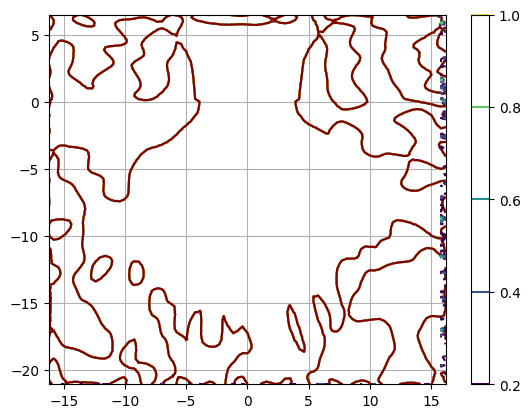

In [756]:
levels = np.linspace(0, 1, 6)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

# device 2

In [785]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

#spacing
dx = (0.0968/1.55) * k_0
dy =  (0.05/1.55) * k_0

# simulation lengths

core_length_x = ((3/1.55) * lambd) * k_0 # W
core_length_y = ((0.1/1.55) * lambd) * k_0 # H

substrate_length_x = ((3.05/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((5.025/1.55) * lambd) * k_0 # Ys

rib_length = ((0.9/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.525/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.36
n_cladding = 1

In [786]:
weights = [1, 1, 1, 1, 1, 1]
m = 2

In [787]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [788]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-789-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-789-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


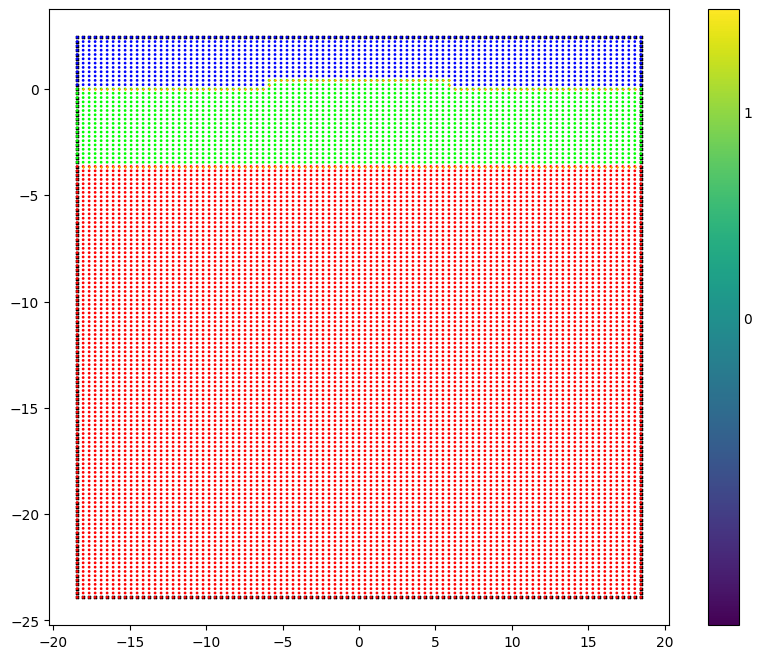

In [789]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [790]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [791]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [792]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [793]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*10
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

0.0001067563789547421


In [794]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

num samples 12445


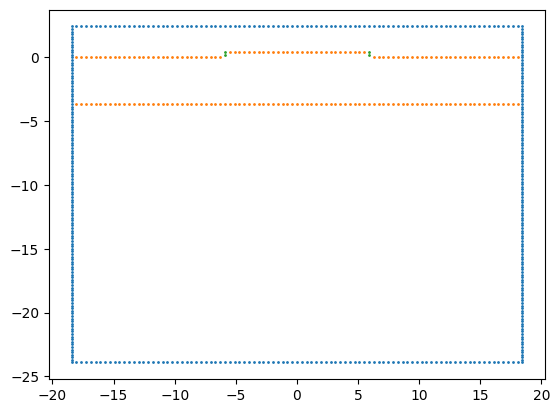

iteration 1 loss1 is 0.61737, loss2 is 41.55814, loss3 is 43.93867, loss4 is 0.0, loss5 is 0.0655, loss6 is 0.94704, total loss 1.629910409450531
2.717224657836743 7.383309841156006
1.279973040386242 1.6383309841156004


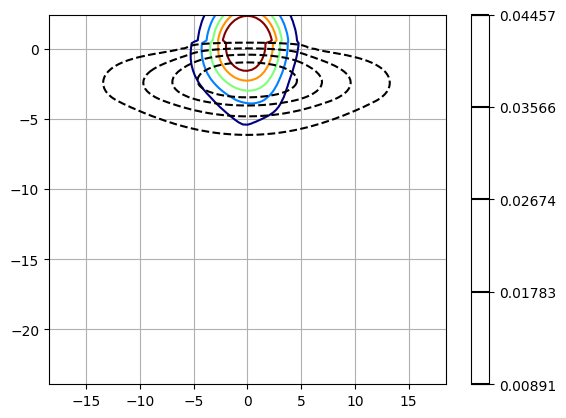

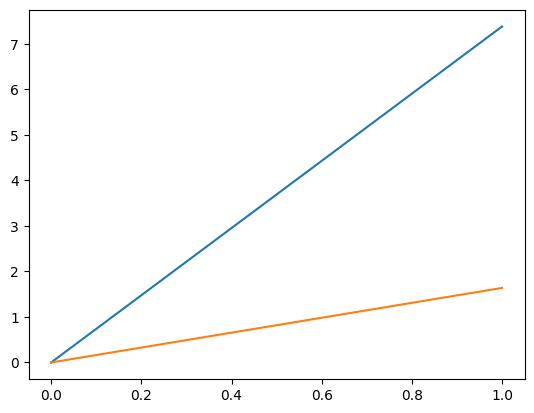

approaching the eigenvalue at 3.3995797178019562 in iteration 149
current learning rate 0.01
learning rate reduced to 0.001
upper and lower bounds: 3.44 3.36
tightened to: 3.4088140329991994 3.3939587422872366
eigen value fixed at 3.3959450697250957 in iteration 627
iteration 1001 loss1 is 0.06942, loss2 is 0.00622, loss3 is 0.70208, loss4 is 0.0, loss5 is 0.00435, loss6 is 0.20751, total loss 0.281286358833313
3.3941783655759385 11.52044677734375
3.3955406867317524 11.52969655525074


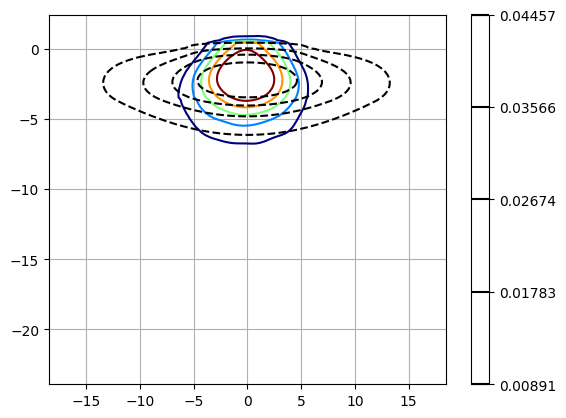

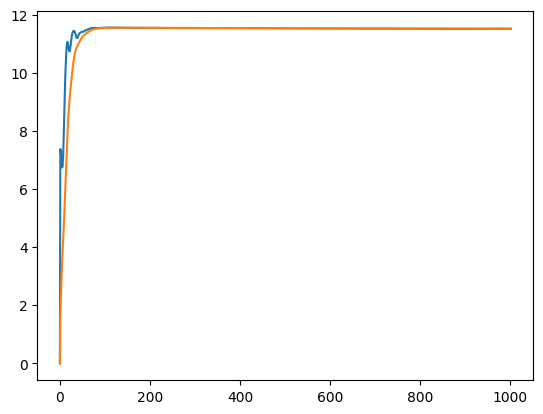

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(5001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx/2, dy/2)

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

In [ ]:
u = u/torch.linalg.norm(u, dim=0, keepdims=True)/np.max(u_fd)
u_fd = u_fd/np.max(u_fd)

In [ ]:
levels = np.linspace(0, 1, 6)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

# device 3

In [ ]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 3 is done for both scalar and TM
# device 3
#spacing
dx = (0.0976/1.55) * k_0
dy =  (0.1/1.55) * k_0

# simulation lengths

core_length_x = ((4/1.55) * lambd) * k_0 # W
core_length_y = ((2.5/1.55) * lambd) * k_0 # H

substrate_length_x = ((4.34/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((7.550/1.55) * lambd) * k_0 # Ys

rib_length = ((3.5/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.55/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.435
n_cladding = 1

In [ ]:
weights = [1, 1, 1, 1, 1, 1]
m = 3

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [ ]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/20)*20
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(3001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

In [ ]:
levels = np.linspace(np.min(u_fd), np.max(u_fd), 6)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.grid()